# Jigsaw puzzle

The task is to reconstruct a complete RGB image of size 96×96 from a set of 9 scrambled image patches of size 28×28×3. The patches originate from a 3×3 partition of the original image, but their spatial arrangement is unknown and part of the border information has been removed through erosion, making the reconstruction problem ambiguous. The model must therefore infer both the correct relative placement of the patches and the missing visual content required to produce a coherent, artifact-free reconstruction of the original image.

In [1]:
import os
import numpy as np
import keras
from keras import layers, models
from keras.utils import PyDataset
import tensorflow as tf

2026-06-05 12:12:54.341816: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780661574.532963      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780661574.589648      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780661575.058596      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780661575.058644      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780661575.058648      58 computation_placer.cc:177] computation placer alr

We use the stanford stl10 dataset, containng 100K color images at resolution (96,96), covering 10 classes: airplane, bird, car, cat, deer, dog, horse, monkey, ship, truck.

Downloading the dataset is time consuming. We recommend to save a local copy.

In [2]:
def download_and_load_stl10():
    # Download and extract the dataset
    path = tf.keras.utils.get_file(
        'stl10_binary.tar.gz',
        origin='http://ai.stanford.edu/~acoates/stl10/stl10_binary.tar.gz',
        extract=True
    )

    # Get the base directory (typically ~/.keras/datasets/)
    base_dir = os.path.dirname(path)

    # Based on your error, we navigate to the extracted subfolder
    data_dir = os.path.join(base_dir, 'stl10_binary_extracted', 'stl10_binary')
    filepath = os.path.join(data_dir, 'unlabeled_X.bin')

    if not os.path.exists(filepath):
        raise FileNotFoundError(f"Could not find the binary file at {filepath}")

    print(f"Loading data from: {filepath}")

    with open(filepath, 'rb') as f:
        # STL-10 unlabeled set contains 100,000 images
        # Data is stored as uint8, (N, C, H, W)
        data = np.fromfile(f, dtype=np.uint8)
        images = np.reshape(data, (-1, 3, 96, 96))

        # Transpose from (N, C, H, W) to (N, H, W, C) for standard image processing
        images = np.transpose(images, (0, 3, 2, 1))

    return images

class PatchGenerator(PyDataset):
    def __init__(self, images, batch_size=32, patch_size=32, crop_size=28, shuffle=True, **kwargs):
        super().__init__(**kwargs)
        self.images = images.astype("float32") / 255.0  # Normalize on the fly or pre-normalize
        self.batch_size = batch_size
        self.patch_size = patch_size
        self.crop_size = crop_size
        self.shuffle = shuffle
        self.indices = np.arange(len(self.images))
        if self.shuffle:
            np.random.shuffle(self.indices)

    def __len__(self):
        return int(np.ceil(len(self.images) / self.batch_size))

    def __getitem__(self, idx):
        batch_indices = self.indices[idx * self.batch_size : (idx + 1) * self.batch_size]
        actual_batch_size = len(batch_indices)

        # X: (Batch, 9 patches, 28, 28, 3)
        # y: (Batch, 9) representing the original position index
        X = np.zeros((actual_batch_size, 9, self.crop_size, self.crop_size, 3), dtype="float32")
        Y = np.zeros((actual_batch_size, 96, 96, 3), dtype="float32")

        for i, img_idx in enumerate(batch_indices):
            full_img = self.images[img_idx]
            Y[i] = full_img
            patches = []

            # Extract 9 patches in a 3x3 grid
            for r in range(3):
                for c in range(3):
                    # Define grid coordinates
                    y_start, x_start = r * self.patch_size, c * self.patch_size
                    patch = full_img[y_start : y_start + self.patch_size,
                                     x_start : x_start + self.patch_size, :]

                    # Center Crop to avoid edge-matching shortcuts (we could go random crop)
                    margin = (self.patch_size - self.crop_size) // 2
                    patch = patch[margin : margin + self.crop_size,
                                  margin : margin + self.crop_size, :]
                    patches.append(patch)

            # Create a permutation (0-8)
            order = np.random.permutation(9)

            for slot_idx, original_pos in enumerate(order):
                X[i, slot_idx] = patches[original_pos]

        return X, Y

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)

In [3]:
# Trigger the download and loading
images = download_and_load_stl10()
print(f"Successfully loaded {images.shape[0]} images.")

2640397119/2640397119 ━━━━━━━━━━━━━━━━━━━━ 208s 0us/step
Loading data from: /root/.keras/datasets/stl10_binary_extracted/stl10_binary/unlabeled_X.bin
Successfully loaded 100000 images.


In [4]:
print(images.shape)

(100000, 96, 96, 3)


In [5]:
train_images = images[:80000]
val_images = images[80000:90000]
test_images = images[90000:]

In [22]:
train_generator = PatchGenerator(train_images, batch_size=8)
val_generator = PatchGenerator(val_images, batch_size=8)
test_generator = PatchGenerator(test_images, batch_size=8)

In [18]:
import tensorflow as tf

def process_jigsaw_image(image):
    """
    Prende un'immagine 96x96, la normalizza, estrae 9 patch 32x32, 
    le croppa a 28x28 e le rimescola. Tutto eseguito nativamente in TensorFlow.
    """
    # 1. Normalizzazione (se l'immagine è ancora in scala 0-255 uint8)
    image = tf.cast(image, tf.float32) / 255.0
    
    # 2. Estrazione vettorializzata delle 9 patch 32x32
    # tf.image.extract_patches richiede la dimensione del batch, quindi espandiamo
    img_exp = tf.expand_dims(image, 0)
    patches = tf.image.extract_patches(
        images=img_exp,
        sizes=[1, 32, 32, 1],
        strides=[1, 32, 32, 1],
        rates=[1, 1, 1, 1],
        padding='VALID'
    )
    
    # Rimodelliamo in (9 patch, 32, 32, 3 canali)
    patches = tf.reshape(patches, (9, 32, 32, 3))
    
    # 3. Center Crop a 28x28 (togliamo 2 pixel da ogni bordo)
    patches = patches[:, 2:30, 2:30, :]
    
    # 4. Rimescolamento (Permutazione)
    indices = tf.random.shuffle(tf.range(9))
    shuffled_patches = tf.gather(patches, indices)
    
    # Ritorna X (input) e Y (ground truth)
    return shuffled_patches, image

def build_fast_dataset(images_array, batch_size=32, is_training=True):
    """Costruisce la pipeline tf.data ottimizzata."""
    ds = tf.data.Dataset.from_tensor_slices(images_array)
    
    if is_training:
        # Mischia l'ordine delle immagini nel dataset
        ds = ds.shuffle(buffer_size=10000)
        
    # Applica la funzione process_jigsaw_image a più immagini in parallelo
    # AUTOTUNE permette a TensorFlow di scegliere dinamicamente quanti core CPU usare
    ds = ds.map(process_jigsaw_image, num_parallel_calls=tf.data.AUTOTUNE)
    
    # Raggruppa in batch e prepara il batch successivo in background (prefetch)
    ds = ds.batch(batch_size)
    ds = ds.prefetch(tf.data.AUTOTUNE)
    
    return ds

# --- 2. Creazione dei Dataset Ultra-Veloci ---
# Passa direttamente i numpy array (es. train_images) creati in precedenza
BATCH_SIZE = 32

train_generator = build_fast_dataset(train_images, batch_size=BATCH_SIZE, is_training=True)
val_generator = build_fast_dataset(val_images, batch_size=BATCH_SIZE, is_training=False)
test_generator= build_fast_dataset(test_images, batch_size=BATCH_SIZE, is_training=False)

Let us inspect the dataset.

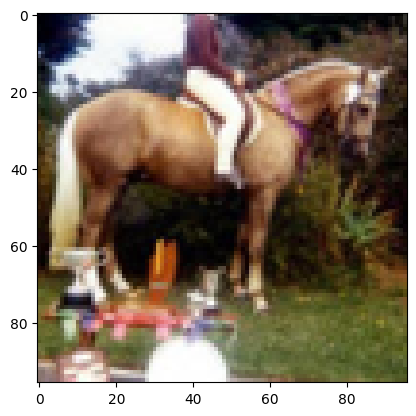

In [19]:
import matplotlib.pyplot as plt
n = np.random.randint(0,test_images.shape[0])
plt.imshow(test_images[n])

Let us now visualize the puzzle

In [20]:
import matplotlib.pyplot as plt
import numpy as np

def plot_puzzle(patches, ordering=None):
    """
    Plots jigsaw patches on a 96x96 canvas.

    Args:
        patches: Array of shape (9, 28, 28, 3)
        ordering: Optional array of shape (9,) or (1, 9) containing
                  the destination grid indices.
    """
    # 1. Handle ordering: if None, use [0, 1, 2... 8]
    if ordering is None:
        order = np.arange(9)
    else:
        order = np.array(ordering).flatten()

    # 2. Setup canvas (96x96x3)
    # Use 1.0 for float images (0.0-1.0) or 255 for uint8 images
    if patches.dtype == np.uint8:
        canvas = np.full((96, 96, 3), 255, dtype=np.uint8)
    else:
        canvas = np.ones((96, 96, 3), dtype=np.float32)

    cell_dim = 32
    patch_dim = 28
    margin = (cell_dim - patch_dim) // 2

    # 3. Place patches
    for i in range(9):
        # Determine destination grid position
        grid_pos = order[i]

        row = grid_pos // 3
        col = grid_pos % 3

        # Calculate canvas pixel coordinates
        y_start = (row * cell_dim) + margin
        y_end = y_start + patch_dim
        x_start = (col * cell_dim) + margin
        x_end = x_start + patch_dim

        # Insert patch i into its grid_pos
        canvas[y_start:y_end, x_start:x_end] = patches[i]

    # 4. Display
    plt.figure(figsize=(5, 5))
    plt.imshow(canvas)
    plt.axis('off')
    plt.show()


In [21]:
a,b = test_generator.__getitem__(1)

AttributeError: '_PrefetchDataset' object has no attribute '__getitem__'

In [ ]:
plt.imshow(b[4])

In [ ]:
plot_puzzle(a[4])

# The problem

Your task is to reconstruct the source (96,96) image from the set of 9 scambled patches of dimension (28,28) each.

**The metric used to measure the quality of the reconstruction must be Mean Absolute Error (MAE).**

Compute MAE over the test set, and also return the standard deviation.


As an indicative baseline, let us compute the MAE relative to the mean patches.

In [11]:
def mean_patch_image(patches):
    #input (B,9,28,28,3)
    B = tf.shape(patches)[0] # Corrected: Use batch size from patches input
    # Mean patch
    mean_patch = tf.reduce_mean(patches, axis=1)  # (B, 28, 28, 3)
    # Replicate 9 times
    mean_patches = tf.repeat(
        mean_patch[:, None, :, :, :],
        repeats=9,
        axis=1
    )
    # Reassemble into 96x96 image
    out = tf.reshape(mean_patches, (B, 3, 3, 28, 28, 3))
    out = tf.transpose(out, [0, 1, 3, 2, 4, 5])
    out = tf.reshape(out, (B, 84, 84, 3))
    out = tf.image.resize(out, (96, 96))
    return out

In [12]:
#compute MAE for mean_patch_image using the test_generator
mae = tf.keras.metrics.MeanAbsoluteError()
mae_values = []
for i in range(len(test_generator)):
    a,b = test_generator.__getitem__(i)
    pred = mean_patch_image(a)
    mae_values.append(mae(pred,b))
print("MAE:", tf.reduce_mean(mae_values))
print("std:", tf.math.reduce_std(mae_values))

AttributeError: '_PrefetchDataset' object has no attribute '__getitem__'

# Additional Constraints

* The solution must rely entirely on neural networks and must not contain non-neural algorithmic components. A pipeline of neural networks is allowed.
* Pretrained models are not permitted.
* The total number of trainable parameters must remain below 6 million. The number of parameters of the proposed solution must be reported explicitly.
* The model weights must be made available for download via gdown. Please verify that the provided link works correctly and that the weights can be loaded successfully.
* The solution must be implemented in Keras and must run on Google Colab. Submissions containing notebook execution errors will be penalized.
* The submission must be a single, well documented notebook file. Tar files will be rejected.





Model

In [14]:
import tensorflow as tf
from tensorflow.keras import layers, Model

# ----------------------- config -----------------------
N_PATCHES, GRID = 9, 3
PATCH_IN, CELL, IMG = 28, 32, 96      # 28->pad->32 ; 3*32 = 96
ENC_C, FEAT_HW = 128, 8               # 32->16->8
D_MODEL, N_HEADS, N_TF_BLOCKS, MLP_RATIO, DROPOUT = 256, 4, 4, 2, 0.1


class LearnedTokens(layers.Layer):
    """A bank of `n` learnable vectors of width `d` (pos-emb / output queries)."""
    def __init__(self, n, d, **kw):
        super().__init__(**kw); self.n, self.d = n, d
    def build(self, _):
        self.w = self.add_weight(name="tok", shape=(1, self.n, self.d), initializer="glorot_uniform")
    def call(self, x):                       # broadcast-add to a (B,n,d) tensor
        return x + self.w


class QueryBank(layers.Layer):
    def __init__(self, n, d, **kw):
        super().__init__(**kw); self.n, self.d = n, d
    def build(self, _):
        self.w = self.add_weight(name="q", shape=(self.n, self.d), initializer="glorot_uniform")
    def call(self, ref):                     # returns (B,n,d) tiled from ref's batch
        b = tf.shape(ref)[0]
        return tf.tile(self.w[None], [b, 1, 1])


def conv_bn(x, f, k=3, s=1):
    x = layers.Conv2D(f, k, strides=s, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    return layers.Activation("relu")(x)

def res_block(x, f):
    s = x
    x = conv_bn(x, f, 3, 1)
    x = layers.Conv2D(f, 3, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    return layers.Activation("relu")(layers.add([x, s]))

def build_patch_encoder():
    inp = layers.Input((CELL, CELL, 3))
    x = conv_bn(inp, 64, 3, 1)
    x = conv_bn(x, 64, 3, 2)               # 16
    x = res_block(x, 64)
    x = conv_bn(x, ENC_C, 3, 2)            # 8
    x = res_block(x, ENC_C)                # 8x8x128
    return Model(inp, x, name="patch_encoder")

def build_patch_decoder():
    f = layers.Input((FEAT_HW, FEAT_HW, ENC_C + D_MODEL))  # feat + tiled context
    x = conv_bn(f, ENC_C, 3, 1)
    x = layers.UpSampling2D()(x)           # 16
    x = conv_bn(x, 64, 3, 1)
    x = layers.UpSampling2D()(x)           # 32
    x = conv_bn(x, 32, 3, 1)
    x = layers.Conv2D(3, 3, padding="same", activation="sigmoid")(x)
    return Model(f, x, name="patch_decoder")

def transformer_block(x, i):
    a = layers.LayerNormalization()(x)
    a = layers.MultiHeadAttention(N_HEADS, D_MODEL // N_HEADS, dropout=DROPOUT,
                                  name=f"mhsa_{i}")(a, a)
    x = layers.add([x, a])
    m = layers.LayerNormalization()(x)
    m = layers.Dense(D_MODEL * MLP_RATIO, activation="gelu")(m)
    m = layers.Dropout(DROPOUT)(m)
    m = layers.Dense(D_MODEL)(m)
    return layers.add([x, m])

def build_model():
    inp = layers.Input((N_PATCHES, PATCH_IN, PATCH_IN, 3), name="patches")
    x = layers.TimeDistributed(layers.ZeroPadding2D(2))(inp)          # (B,9,32,32,3)

    feat = layers.TimeDistributed(build_patch_encoder())(x)          # (B,9,8,8,128)
    tok  = layers.TimeDistributed(layers.GlobalAveragePooling2D())(feat)  # (B,9,128)
    tok  = layers.Dense(D_MODEL)(tok)                                # (B,9,256)
    t    = LearnedTokens(N_PATCHES, D_MODEL, name="pos_emb")(tok)

    for i in range(N_TF_BLOCKS):
        t = transformer_block(t, i)                                  # (B,9,256)

    # ---- soft-permutation assembler: output-cell queries x input tokens ----
    q = QueryBank(N_PATCHES, D_MODEL, name="out_queries")(t)
    q = layers.Dense(D_MODEL)(q)
    k = layers.Dense(D_MODEL)(t)
    scores = layers.Lambda(lambda z: tf.einsum("bod,bid->boi", z[0], z[1])
                           / (D_MODEL ** 0.5))([q, k])               # (B,9,9)
    A = layers.Softmax(-1, name="assignment")(scores)

    feat_r = layers.Lambda(lambda z: tf.einsum("boi,bihwc->bohwc", z[0], z[1]),
                           name="route_feat")([A, feat])             # (B,9,8,8,128)
    tok_r  = layers.Lambda(lambda z: tf.einsum("boi,bid->bod", z[0], z[1]),
                           name="route_tok")([A, t])                 # (B,9,256)

    ctx = layers.Lambda(lambda z: tf.tile(z[:, :, None, None, :],
                                          [1, 1, FEAT_HW, FEAT_HW, 1]))(tok_r)
    dec_in = layers.Concatenate(-1)([feat_r, ctx])                   # (B,9,8,8,384)
    cells = layers.TimeDistributed(build_patch_decoder())(dec_in)   # (B,9,32,32,3)

    def tile(c):
        b = tf.shape(c)[0]
        c = tf.reshape(c, (b, GRID, GRID, CELL, CELL, 3))
        c = tf.transpose(c, (0, 1, 3, 2, 4, 5))
        return tf.reshape(c, (b, IMG, IMG, 3))
    coarse = layers.Lambda(tile, name="assemble")(cells)            # (B,96,96,3)

    # ---- full-image refinement (seam inpainting), residual in logit space ----
    r = conv_bn(coarse, 32, 3, 1)
    r = res_block(r, 32)
    r = layers.Conv2D(3, 3, padding="same")(r)
    logit = layers.Lambda(lambda z: tf.math.log(z + 1e-4) - tf.math.log(1 - z + 1e-4))(coarse)
    out = layers.Activation("sigmoid", name="reconstruction")(layers.add([logit, r]))

    model = Model(inp, out, name="jigsaw_inpaint")
    model.compile(tf.keras.optimizers.Adam(3e-4), loss="mae", metrics=["mae"])
    return model

model = build_model()
model.summary()

Model: "jigsaw_inpaint"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ patches             │ (None, 9, 28, 28, │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed    │ (None, 9, 32, 32, │          0 │ patches[0][0]     │
│ (TimeDistributed)   │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_1  │ (None, 9, 8, 8,   │    483,520 │ time_distributed… │
│ (TimeDistributed)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_2  │ (None, 9, 128)    │          0 │ time_distributed… │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 9, 256)    │     33,024 │ time_distributed… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pos_emb             │ (None, 9, 256)    │      2,304 │ dense_8[0][0]     │
│ (LearnedTokens)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 9, 256)    │        512 │ pos_emb[0][0]     │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mhsa_0              │ (None, 9, 256)    │    263,168 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_14 (Add)        │ (None, 9, 256)    │          0 │ pos_emb[0][0],    │
│                     │                   │            │ mhsa_0[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 9, 256)    │        512 │ add_14[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 9, 512)    │    131,584 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 9, 512)    │          0 │ dense_9[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 9, 256)    │    131,328 │ dropout_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_15 (Add)        │ (None, 9, 256)    │          0 │ add_14[0][0],     │
│                     │                   │            │ dense_10[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 9, 256)    │        512 │ add_15[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mhsa_1              │ (None, 9, 256)    │    263,168 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_16 (Add)        │ (None, 9, 256)    │          0 │ add_15[0][0],     │
│                     │                   │            │ mhsa_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 9, 256)    │        512 │ add_16[0][0]      │
│ (LayerNormalizatio… │                   │            │                 

 Total params: 3,317,990 (12.66 MB)

 Trainable params: 3,316,070 (12.65 MB)

 Non-trainable params: 1,920 (7.50 KB)

In [15]:
import tensorflow as tf
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
import time

@keras.saving.register_keras_serializable(name="mae_ssim_loss")
def mae_ssim_loss(y_true, y_pred):
    # Calcolo L1 Loss (MAE)
    l1_loss = tf.reduce_mean(tf.abs(y_true - y_pred))
    
    # Calcolo SSIM Loss (valori tra 0 e 1, dove più basso è meglio)
    ssim_value = tf.image.ssim(y_true, y_pred, max_val=1.0)
    ssim_loss = tf.reduce_mean((1.0 - ssim_value) / 2.0)
    
    # Combinazione pesata (84% importanza alla struttura, 16% ai colori esatti)
    alpha = 0.84 
    return alpha * ssim_loss + (1 - alpha) * l1_loss

# --- 1. CONFIGURAZIONE LOSS E OTTIMIZZATORE ---
# Usiamo il MAE sia come Loss (per aggiornare i pesi) sia come Metrica
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss= tf.keras.losses.MeanAbsoluteError(),#mae_ssim_loss
    metrics=[tf.keras.metrics.MeanAbsoluteError(name='mae')]
)

# --- 2. DEFINIZIONE DELLE CALLBACKS ---
# Salva solo i pesi del modello quando la validation loss migliora
checkpoint = ModelCheckpoint(
    filepath='best_jigsaw_weights.weights.h5', 
    save_weights_only=True,
    monitor='val_loss', 
    mode='min', 
    save_best_only=True,
    verbose=1
)

# Riduci il learning rate se la rete smette di imparare (plateau)
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss', 
    factor=0.1, 
    patience=0, 
    min_lr=1e-6, 
    verbose=1
)

# Ferma l'addestramento in anticipo se la rete va in overfitting
early_stopping = EarlyStopping(
    monitor='val_loss', 
    patience=2, 
    restore_best_weights=True,
    verbose=1
)

# --- 3. TRAINING LOOP ---
EPOCHS = 30 # Puoi aumentare questo valore, l'EarlyStopping fermerà il training se necessario

print("Inizio dell'addestramento...")
start_time = time.time()

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    callbacks=[checkpoint, reduce_lr, early_stopping],
    verbose=1 # Usa verbose=1 in Colab per vedere la barra di progresso
)

print(f"Addestramento completato in {(time.time() - start_time)/60:.2f} minuti.")

Inizio dell'addestramento...
Epoch 1/30


I0000 00:00:1780662102.327997     127 service.cc:152] XLA service 0x7f20b8002180 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1780662102.328066     127 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1780662109.104675     127 cuda_dnn.cc:529] Loaded cuDNN version 91002


   2/2500 ━━━━━━━━━━━━━━━━━━━━ 3:01 73ms/step - loss: 0.2986 - mae: 0.2986   

I0000 00:00:1780662135.806956     127 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


2500/2500 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - loss: 0.1519 - mae: 0.1519
Epoch 1: val_loss improved from None to 0.12461, saving model to best_jigsaw_weights.weights.h5

Epoch 1: finished saving model to best_jigsaw_weights.weights.h5
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 253s 75ms/step - loss: 0.1363 - mae: 0.1363 - val_loss: 0.1246 - val_mae: 0.1246 - learning_rate: 0.0010
Epoch 2/30
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - loss: 0.1160 - mae: 0.1160
Epoch 2: val_loss improved from 0.12461 to 0.10851, saving model to best_jigsaw_weights.weights.h5

Epoch 2: finished saving model to best_jigsaw_weights.weights.h5
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 175s 70ms/step - loss: 0.1131 - mae: 0.1131 - val_loss: 0.1085 - val_mae: 0.1085 - learning_rate: 0.0010
Epoch 3/30
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - loss: 0.1055 - mae: 0.1055
Epoch 3: val_loss improved from 0.10851 to 0.09702, saving model to best_jigsaw_weights.weights.h5

Epoch 3: finished saving model to best_jigsaw_weights.weight

In [23]:
import numpy as np

print("Calcolo del MAE e della Standard Deviation sul Test Set...")

# Liste per accumulare gli errori assoluti per ogni batch del test set
mae_metric = tf.keras.metrics.MeanAbsoluteError()
mae_values = []

# Iteriamo sul test_generator
for i in range(len(test_generator)):
    # Estrarre il batch: 'X' sono le patch mischiate, 'Y' è l'immagine target 96x96
    X_batch, Y_batch = test_generator[i]
    
    # Facciamo la predizione
    predictions = model.predict(X_batch, verbose=0)
    
    # Calcoliamo l'errore per questo batch e lo salviamo
    batch_mae = mae_metric(Y_batch, predictions)
    mae_values.append(batch_mae.numpy())

# Calcolo del MAE totale e della Deviazione Standard
final_mae = np.mean(mae_values)
final_std = np.std(mae_values)

print(f"=====================================")
print(f"Risultati Finali sul Test Set:")
print(f"MAE: {final_mae:.6f}")
print(f"Standard Deviation: {final_std:.6f}")
print(f"=====================================")

# Ricorda che la baseline banale era ~0.1825. 
# Il nostro obiettivo è avere un MAE significativamente più basso!

Calcolo del MAE e della Standard Deviation sul Test Set...
Risultati Finali sul Test Set:
MAE: 0.062882
Standard Deviation: 0.000711


Generazione delle immagini in corso...


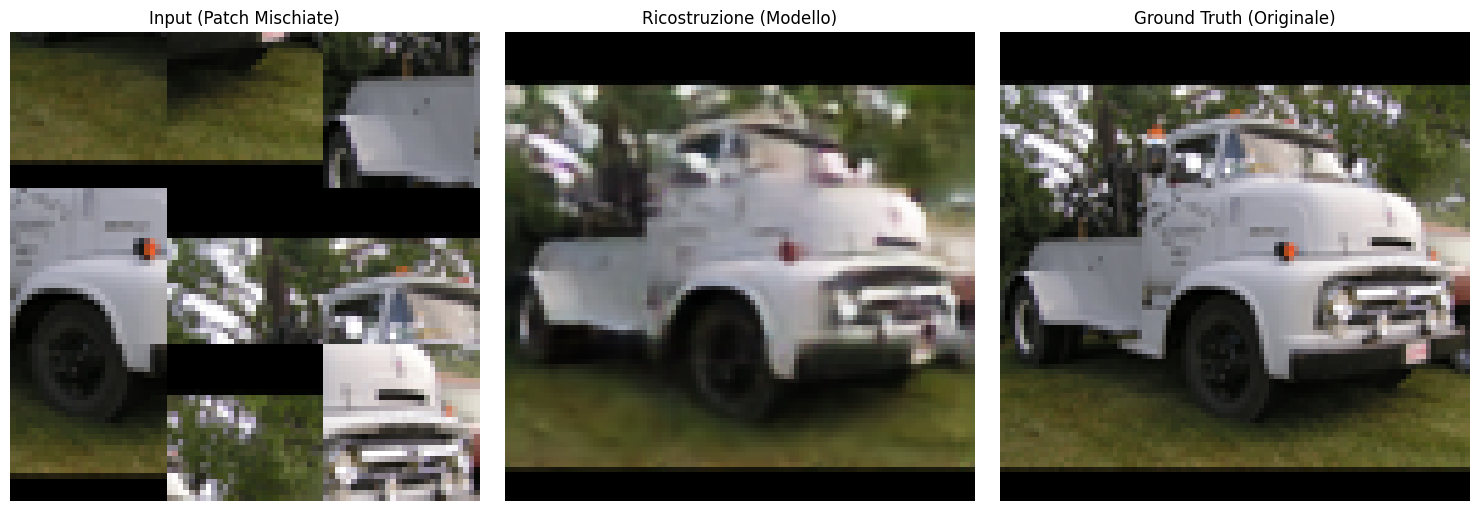

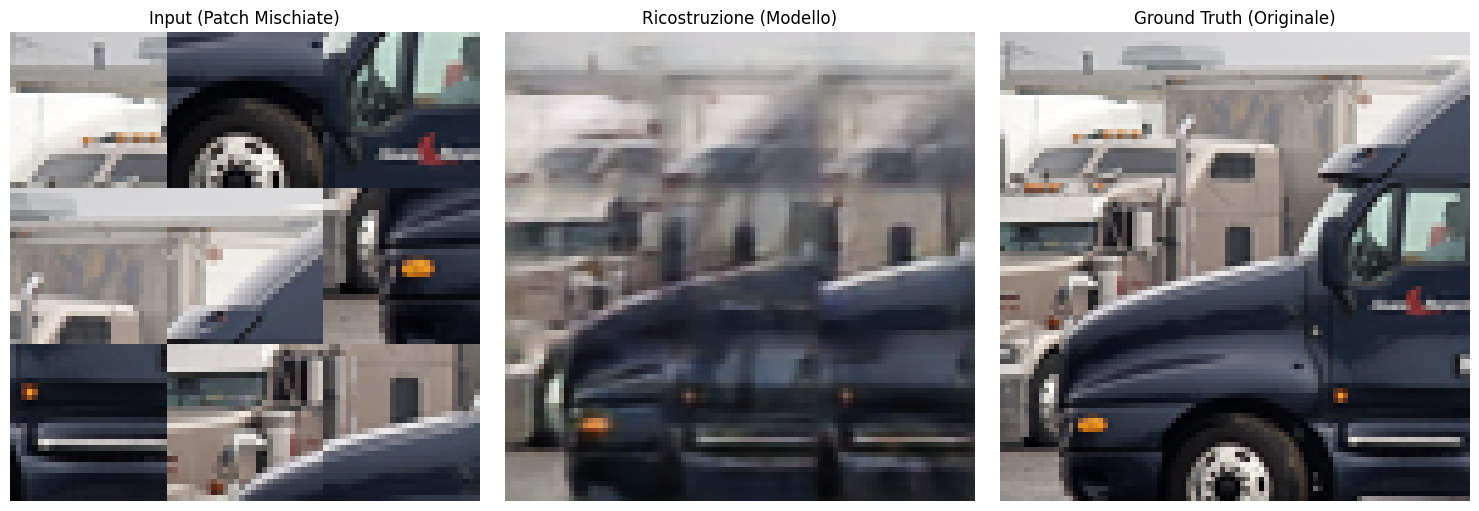

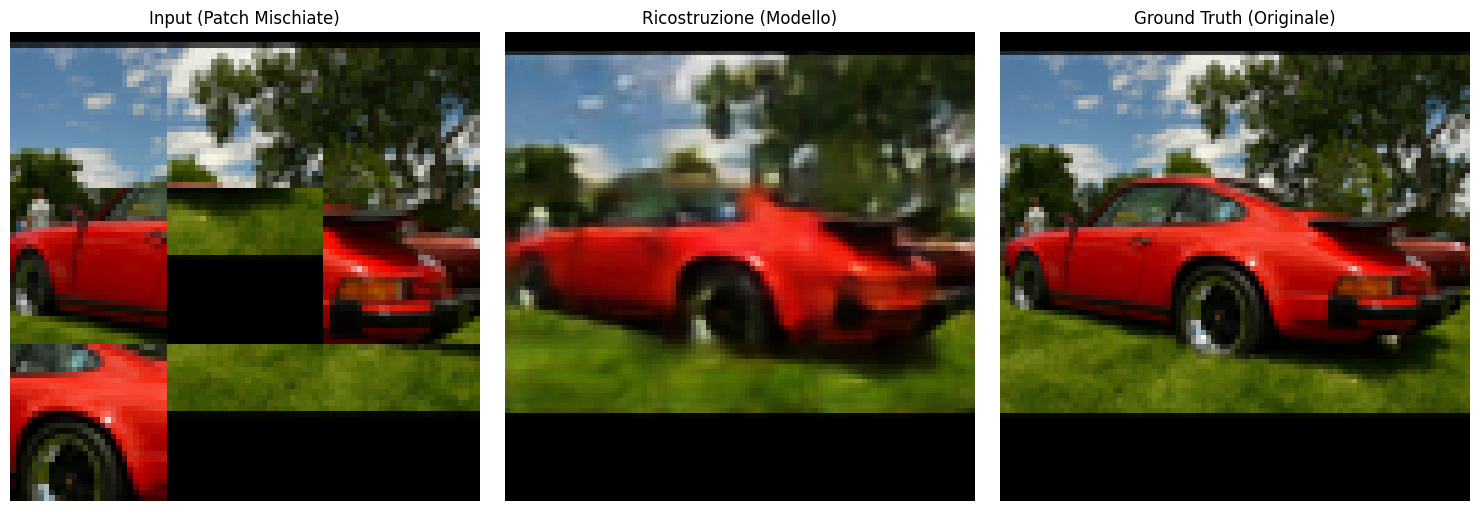

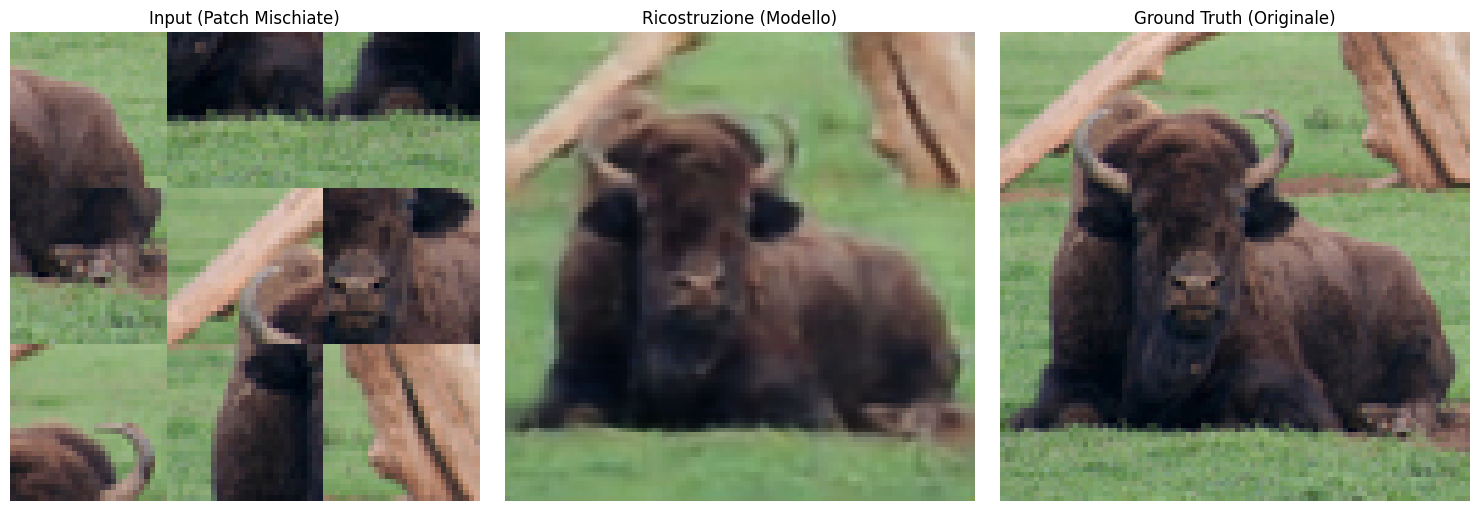

In [24]:
import matplotlib.pyplot as plt
import numpy as np

def visualize_reconstruction(model, generator, num_examples=3):
    """
    Seleziona immagini dal generatore, effettua la ricostruzione tramite il modello
    e plotta Input, Ricostruzione e Ground Truth affiancati.
    """
    print("Generazione delle immagini in corso...")
    
    # Estraiamo un singolo batch dal generatore di test
    X_batch, Y_batch = generator[0]
    
    # Il modello predice la ricostruzione per l'intero batch
    Y_pred = model.predict(X_batch, verbose=0)
    
    # Selezioniamo casualmente 'num_examples' indici dal batch
    # Assicuriamoci che num_examples non sia superiore alla grandezza del batch
    max_examples = min(num_examples, X_batch.shape[0])
    indices = np.random.choice(X_batch.shape[0], max_examples, replace=False)
    
    for idx in indices:
        fig, axes = plt.subplots(1, 3, figsize=(15, 5))
        
        # --- 1. Input (Patch Mischiate) ---
        # I tasselli in input sono 9 e misurano 28x28. Li cuciamo insieme in una griglia 3x3 (84x84)
        # solo per far capire visivamente alla giuria/professore quanto era difficile l'input.
        patches = X_batch[idx]
        scrambled_grid = np.zeros((84, 84, 3))
        for row in range(3):
            for col in range(3):
                patch_idx = row * 3 + col
                scrambled_grid[row*28:(row+1)*28, col*28:(col+1)*28] = patches[patch_idx]
                
        axes[0].imshow(scrambled_grid)
        axes[0].set_title("Input (Patch Mischiate)")
        axes[0].axis('off')
        
        # --- 2. Ricostruzione del Modello ---
        # L'output della rete è 96x96x3
        # Usiamo np.clip per assicurarci che i valori siano rigorosamente tra 0 e 1 per matplotlib
        reconstructed_img = np.clip(Y_pred[idx], 0.0, 1.0)
        axes[1].imshow(reconstructed_img)
        axes[1].set_title("Ricostruzione (Modello)")
        axes[1].axis('off')
        
        # --- 3. Ground Truth (Immagine Originale) ---
        # L'obiettivo target reale 96x96x3
        original_img = np.clip(Y_batch[idx], 0.0, 1.0)
        axes[2].imshow(original_img)
        axes[2].set_title("Ground Truth (Originale)")
        axes[2].axis('off')
        
        plt.tight_layout()
        plt.show()

# Eseguiamo la funzione passando il modello addestrato e il generatore di test
visualize_reconstruction(model, test_generator, num_examples=4)